# Impact Of Online And Offline Education On Student Performance And Engagement

**Group 3**

Ramandeep Singh

Tran Bao Diem Phuong

Devansh Sharma

Gaurav Sunil Kumar Singh

Keying Wang

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'D:\SEM 3\Impact of Online and Offline Education on Student Performance and Engagement (Responses) - Form Responses 1 (3).csv')

In [3]:
df.columns

Index(['Timestamp', '1. What is your current level of education? ',
       '2. What is your gender? ', '3. What is your primary field of study? ',
       '4. Are you a domestic or foreign (international) student? ',
       '5.  Are you currently working full-time or part-time while studying?',
       '6. Which mode of education do you prefer?',
       '7. Have you taken any online courses in the past year?',
       '8(a) . What factors influence your choice of online  education?  (select all that apply)',
       '8(b).  What factors influence your choice of offline education?  (select all that apply)',
       '9. How do you rate the effectiveness of online education on a scale of 1 to 5 (1 being ineffective, 5 being very effective)?',
       '10. What challenges do you face in online education?  (select all that apply)',
       '11. How often do you engage with your instructors during online courses?',
       '12. How satisfied are you with the quality of learning materials provided in

**Renames Columns in the DataFrame**

In [4]:
df.rename(columns={
    'Timestamp': 'Timestamp',
    '1. What is your current level of education? ': 'Education_Level',
    '2. What is your gender? ': 'Gender',
    '3. What is your primary field of study? ': 'Field_of_Study',
    '4. Are you a domestic or foreign (international) student? ': 'Domestic_or_International',
    '5.  Are you currently working full-time or part-time while studying?': 'Work_Status',
    '6. Which mode of education do you prefer?': 'Education_Mode',
    '7. Have you taken any online courses in the past year?': 'Online_Courses_Last_Year',
    '8(a) . What factors influence your choice of online  education?  (select all that apply)': 'Online_Influence_Factors',
    '8(b).  What factors influence your choice of offline education?  (select all that apply)': 'Offline_Influence_Factors',
    '9. How do you rate the effectiveness of online education on a scale of 1 to 5 (1 being ineffective, 5 being very effective)?': 'Online_Effectiveness',
    '10. What challenges do you face in online education?  (select all that apply)': 'Online_Challenges',
    '11. How often do you engage with your instructors during online courses?': 'Online_Student_Engagement',
    '12. How satisfied are you with the quality of learning materials provided in online courses?': 'Online_Material_Satisfaction',
    '13. Do you feel that online education provides enough opportunities for collaboration and interaction with other students?': 'Online_Collaboration',
    '14. What benefits do you find in offline education compared to online education?  (select all that apply)': 'Offline_Benefits',
    '15. How satisfied are you with the availability of learning resources (labs, libraries) in offline education? ': 'Offline_Resources_Satisfaction',
    '16. How would you rate the classroom environment in terms of engagement and participation? ': 'Offline_Classroom_Engagement',
    '17. Do you feel more motivated to study in an offline (in-person) setting compared to an online one? ': 'Offline_Motivation',
    ' 18.  Which mode of education has helped you achieve better grades or academic results?  ': 'Better_Grades_Mode',
    '19. In your opinion, which mode of education, online or offline, better prepares you for getting a job?"  ': 'Job_Preparation_Mode'
}, inplace=True)

# Display the updated column names to confirm renaming
print("Renamed Columns:")
print(df.columns.tolist())

Renamed Columns:
['Timestamp', 'Education_Level', 'Gender', 'Field_of_Study', 'Domestic_or_International', 'Work_Status', 'Education_Mode', 'Online_Courses_Last_Year', 'Online_Influence_Factors', 'Offline_Influence_Factors', 'Online_Effectiveness', 'Online_Challenges', 'Online_Student_Engagement', 'Online_Material_Satisfaction', 'Online_Collaboration', 'Offline_Benefits', 'Offline_Resources_Satisfaction', 'Offline_Classroom_Engagement', 'Offline_Motivation', 'Better_Grades_Mode', 'Job_Preparation_Mode']


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Timestamp                       204 non-null    object
 1   Education_Level                 204 non-null    object
 2   Gender                          204 non-null    object
 3   Field_of_Study                  204 non-null    object
 4   Domestic_or_International       204 non-null    object
 5   Work_Status                     204 non-null    object
 6   Education_Mode                  204 non-null    object
 7   Online_Courses_Last_Year        204 non-null    object
 8   Online_Influence_Factors        204 non-null    object
 9   Offline_Influence_Factors       204 non-null    object
 10  Online_Effectiveness            204 non-null    int64 
 11  Online_Challenges               204 non-null    object
 12  Online_Student_Engagement       204 non-null    ob

In [6]:
df

,Timestamp,Education_Level,Gender,Field_of_Study,Domestic_or_International,Work_Status,Education_Mode,Online_Courses_Last_Year,Online_Influence_Factors,Offline_Influence_Factors,...,Online_Challenges,Online_Student_Engagement,Online_Material_Satisfaction,Online_Collaboration,Offline_Benefits,Offline_Resources_Satisfaction,Offline_Classroom_Engagement,Offline_Motivation,Better_Grades_Mode,Job_Preparation_Mode
0,10/20/2024 22:41:42,Graduate,Male,data analytics,Foreign (International) student,Not working,Offline (In-person),No,"Convenience of location, Interaction with peer...","Cost, Convenience of location",...,"Difficulty staying motivated, Lack of access t...",Sometimes,Satisfied,No,More engaging learning environment,Satisfied,Good,Neutral,Offline,Offline
1,10/20/2024 22:44:07,Graduate,Male,data analytics,Foreign (International) student,Not working,Online,No,Quality of education,Convenience of location,...,Lack of access to course materials,Rarely,Satisfied,No,"More engaging learning environment, More struc...",Satisfied,Good,Neutral,Offline,Offline
2,10/22/2024 9:37:38,Undergraduate,Male,data analytics,Foreign (International) student,Not working,Offline (In-person),No,"Convenience of location, Interaction with peer...","Quality of education, Face-to-face interaction...",...,"Technical difficulties, Lack of access to cour...",Sometimes,Satisfied,No,"More engaging learning environment, Better acc...",Satisfied,Good,Neutral,Offline,Offline
3,10/22/2024 9:39:18,Undergraduate,Female,data analytics,Foreign (International) student,Full-time,Offline (In-person),No,"Convenience of location, Interaction with peer...","Cost, Quality of education, Face-to-face inter...",...,"Difficulty staying motivated, Lack of access t...",Sometimes,Satisfied,Yes,"Easier to focus, More engaging learning enviro...",Neutral,Average,Neutral,Online,Online
4,10/22/2024 9:40:00,Graduate,Male,data analytics,Foreign (International) student,Full-time,Online,Yes,"Flexibility in schedule, Cost, Convenience of ...","Quality of education, Face-to-face interaction...",...,Technical difficulties,Very often,Very satisfied,Yes,Better interaction with instructors,Neutral,Average,Strongly disagree,Online,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,11/15/2024 21:11:31,Graduate,Male,engineering,Foreign (International) student,Full-time,Online,Yes,"Flexibility in schedule, Convenience of locati...","Cost, Convenience of location, Availability of...",...,Lack of interaction with peers,Sometimes,Very satisfied,No,Easier to focus,Very satisfied,Excellent,Disagree,Online,Online
200,11/15/2024 22:28:46,Graduate,Female,science,Foreign (International) student,Not working,Offline (In-person),No,"Convenience of location, Avoiding travel/commu...","Flexibility in schedule, Quality of education,...",...,"Poor internet connection, Lack of interaction ...",Very often,Satisfied,Yes,"Better interaction with instructors, More enga...",Very satisfied,Excellent,Strongly agree,Offline,Offline
201,11/15/2024 22:41:04,Graduate,Male,engineering,Foreign (International) student,Part-time,Online,Yes,"Flexibility in schedule, Cost, Convenience of ...","Flexibility in schedule, Convenience of location",...,"Poor internet connection, Lack of interaction ...",Never,Very satisfied,Yes,Better interaction with instructors,Very satisfied,Excellent,Strongly agree,Online,Online
202,11/16/2024 1:18:37,Graduate,Male,information & technology,Foreign (International) student,Part-time,Online,Yes,"Flexibility in schedule, Avoiding travel/commu...",Face-to-face interaction with instructors and ...,...,Lack of access to course materials,Very often,Neutral,Yes,Better interaction with instructors,Neutral,Average,Neutral,Online,Online


In [7]:
df.head()

,Timestamp,Education_Level,Gender,Field_of_Study,Domestic_or_International,Work_Status,Education_Mode,Online_Courses_Last_Year,Online_Influence_Factors,Offline_Influence_Factors,...,Online_Challenges,Online_Student_Engagement,Online_Material_Satisfaction,Online_Collaboration,Offline_Benefits,Offline_Resources_Satisfaction,Offline_Classroom_Engagement,Offline_Motivation,Better_Grades_Mode,Job_Preparation_Mode
0,10/20/2024 22:41:42,Graduate,Male,data analytics,Foreign (International) student,Not working,Offline (In-person),No,"Convenience of location, Interaction with peer...","Cost, Convenience of location",...,"Difficulty staying motivated, Lack of access t...",Sometimes,Satisfied,No,More engaging learning environment,Satisfied,Good,Neutral,Offline,Offline
1,10/20/2024 22:44:07,Graduate,Male,data analytics,Foreign (International) student,Not working,Online,No,Quality of education,Convenience of location,...,Lack of access to course materials,Rarely,Satisfied,No,"More engaging learning environment, More struc...",Satisfied,Good,Neutral,Offline,Offline
2,10/22/2024 9:37:38,Undergraduate,Male,data analytics,Foreign (International) student,Not working,Offline (In-person),No,"Convenience of location, Interaction with peer...","Quality of education, Face-to-face interaction...",...,"Technical difficulties, Lack of access to cour...",Sometimes,Satisfied,No,"More engaging learning environment, Better acc...",Satisfied,Good,Neutral,Offline,Offline
3,10/22/2024 9:39:18,Undergraduate,Female,data analytics,Foreign (International) student,Full-time,Offline (In-person),No,"Convenience of location, Interaction with peer...","Cost, Quality of education, Face-to-face inter...",...,"Difficulty staying motivated, Lack of access t...",Sometimes,Satisfied,Yes,"Easier to focus, More engaging learning enviro...",Neutral,Average,Neutral,Online,Online
4,10/22/2024 9:40:00,Graduate,Male,data analytics,Foreign (International) student,Full-time,Online,Yes,"Flexibility in schedule, Cost, Convenience of ...","Quality of education, Face-to-face interaction...",...,Technical difficulties,Very often,Very satisfied,Yes,Better interaction with instructors,Neutral,Average,Strongly disagree,Online,Online


In [8]:
df.columns

Index(['Timestamp', 'Education_Level', 'Gender', 'Field_of_Study',
       'Domestic_or_International', 'Work_Status', 'Education_Mode',
       'Online_Courses_Last_Year', 'Online_Influence_Factors',
       'Offline_Influence_Factors', 'Online_Effectiveness',
       'Online_Challenges', 'Online_Student_Engagement',
       'Online_Material_Satisfaction', 'Online_Collaboration',
       'Offline_Benefits', 'Offline_Resources_Satisfaction',
       'Offline_Classroom_Engagement', 'Offline_Motivation',
       'Better_Grades_Mode', 'Job_Preparation_Mode'],
      dtype='object')

**Find Missing Values**

In [9]:
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values)

Missing Values per Column:
Timestamp                         0
Education_Level                   0
Gender                            0
Field_of_Study                    0
Domestic_or_International         0
Work_Status                       0
Education_Mode                    0
Online_Courses_Last_Year          0
Online_Influence_Factors          0
Offline_Influence_Factors         0
Online_Effectiveness              0
Online_Challenges                 0
Online_Student_Engagement         0
Online_Material_Satisfaction      0
Online_Collaboration              0
Offline_Benefits                  0
Offline_Resources_Satisfaction    0
Offline_Classroom_Engagement      0
Offline_Motivation                0
Better_Grades_Mode                0
Job_Preparation_Mode              0
dtype: int64


**Find Duplicate Values**

In [10]:
df.duplicated().sum()

0

**Converting Timestamp Column to Datetime Format**

In [11]:
# Convert 'Timestamp' column to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M:%S', errors='coerce')


In [12]:
# Count unique values in each column

columns_to_check = ['Education_Level', 'Gender', 'Field_of_Study',
                   'Domestic_or_International', 'Work_Status',
                   'Education_Mode', 'Online_Courses_Last_Year',
                   'Online_Effectiveness', 'Online_Student_Engagement',
                   'Online_Material_Satisfaction', 'Online_Collaboration',
                   'Offline_Resources_Satisfaction', 'Offline_Classroom_Engagement',
                   'Offline_Motivation', 'Better_Grades_Mode', 'Job_Preparation_Mode']

for col in columns_to_check:
  unique_values = df[col].unique()
  print(f"Unique values for column '{col}':")
  print(unique_values)
  print("-" * 20)

Unique values for column 'Education_Level':
['Graduate' 'Undergraduate' 'High School']
--------------------
Unique values for column 'Gender':
['Male' 'Female' 'Prefer not to say']
--------------------
Unique values for column 'Field_of_Study':
['data analytics' 'business' 'information & technology' 'engineering'
 'other' 'science' 'arts' 'commerce' 'medical']
--------------------
Unique values for column 'Domestic_or_International':
['Foreign (International) student' 'Domestic student']
--------------------
Unique values for column 'Work_Status':
['Not working' 'Full-time' 'Part-time']
--------------------
Unique values for column 'Education_Mode':
['Offline (In-person)' 'Online']
--------------------
Unique values for column 'Online_Courses_Last_Year':
['No' 'Yes']
--------------------
Unique values for column 'Online_Effectiveness':
[5 3 1 4 2]
--------------------
Unique values for column 'Online_Student_Engagement':
['Sometimes' 'Rarely' 'Very often' 'Never']
--------------------


# univariate Analysis

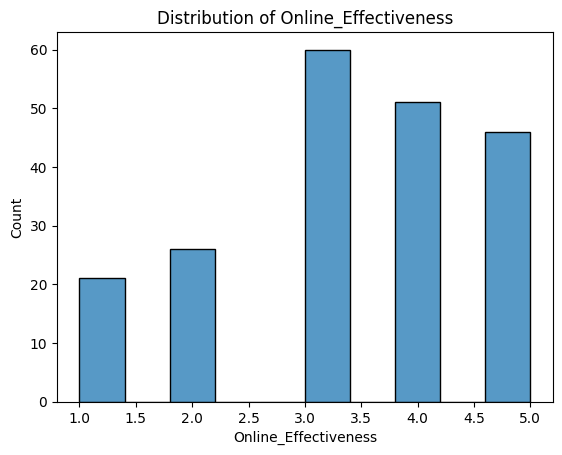

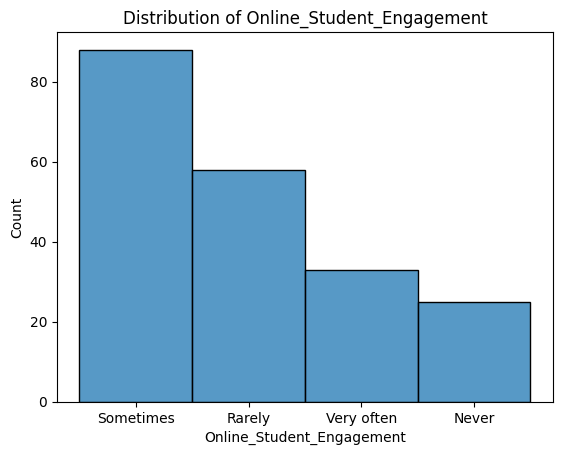

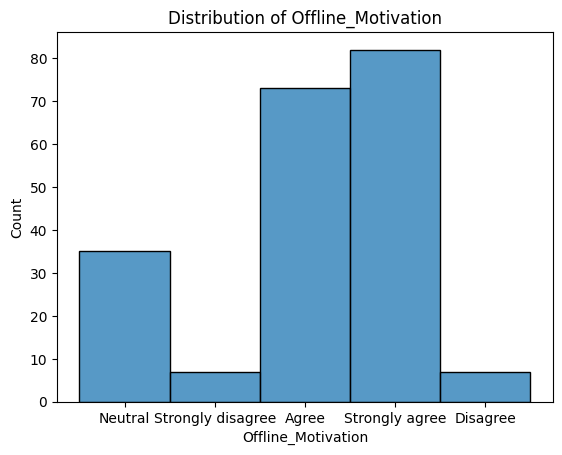

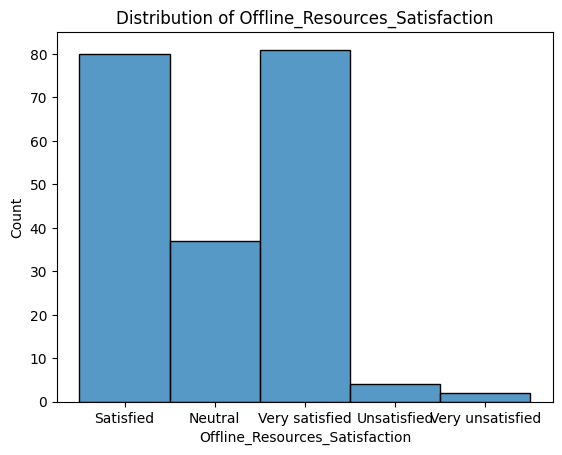

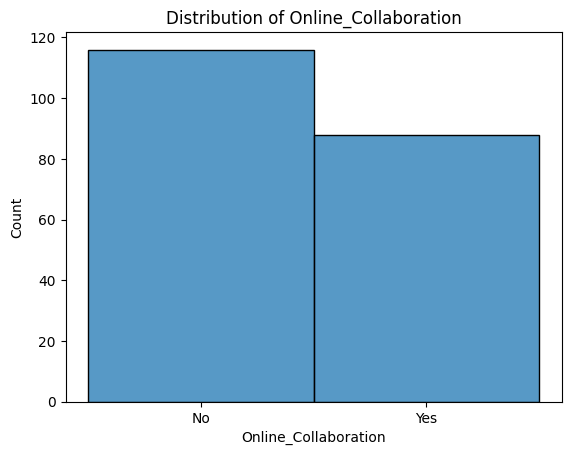

In [13]:
# Distribution Analysis
selected_columns = ['Online_Effectiveness', 'Online_Student_Engagement', 'Offline_Motivation', 'Offline_Resources_Satisfaction', 'offline_Classroom_Engagement','Online_Collaboration']
for column in selected_columns:
    if column in df.columns:
        sns.histplot(df[column], bins=10)
        plt.title(f"Distribution of {column}")
        plt.show()





# Bivariate Analysis

Better_Grades_Mode
Offline    141
Online      63
Name: Education_Mode, dtype: int64


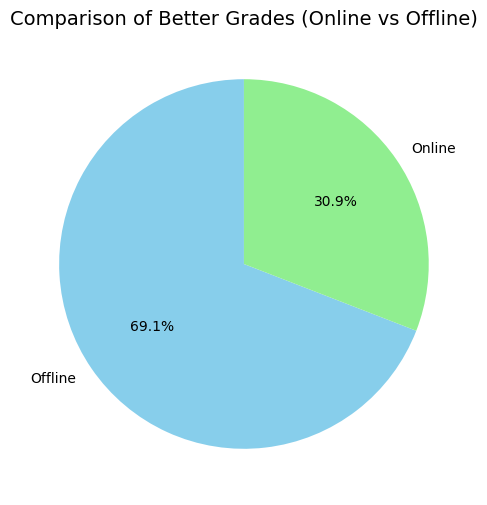

In [14]:
# Compare the effect of online and offline education on student performance

performance_comparison = df.groupby('Better_Grades_Mode')['Education_Mode'].count()
print(performance_comparison)

# Visualization of performance comparison
plt.figure(figsize=(8, 6))
plt.pie(
    performance_comparison,
    labels=performance_comparison.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen']
)
plt.title('Comparison of Better Grades (Online vs Offline)', fontsize=14)
plt.show()


Demographic Summary:
 Education_Level  Gender             Domestic_or_International        Education_Mode     
Graduate         Female             Domestic student                 Offline (In-person)     5
                                                                     Online                  3
                                    Foreign (International) student  Offline (In-person)    36
                                                                     Online                  3
                 Male               Domestic student                 Offline (In-person)     8
                                                                     Online                  2
                                    Foreign (International) student  Offline (In-person)    38
                                                                     Online                 30
                 Prefer not to say  Foreign (International) student  Offline (In-person)     1
High School      Female          

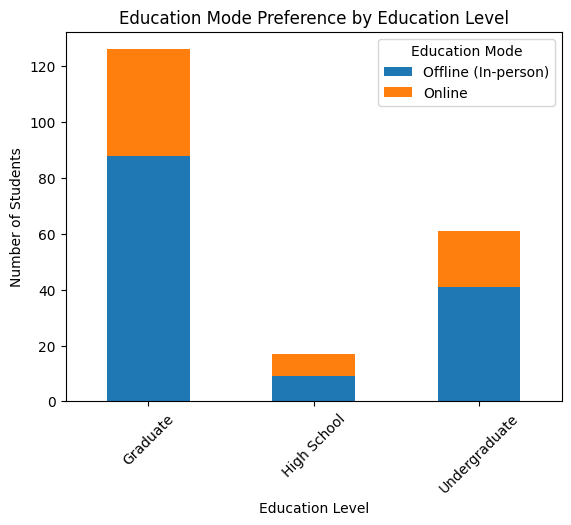

In [15]:
# Influence of demographic factors
demographic_summary = df.groupby(['Education_Level', 'Gender', 'Domestic_or_International', 'Education_Mode']).size()
print("\nDemographic Summary:\n", demographic_summary)

# Bar plot for education mode preference by education level
education_mode_by_level = df.groupby(['Education_Level', 'Education_Mode']).size().unstack()
education_mode_by_level.plot(kind='bar', stacked=True, title="Education Mode Preference by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.legend(title="Education Mode")
plt.show()

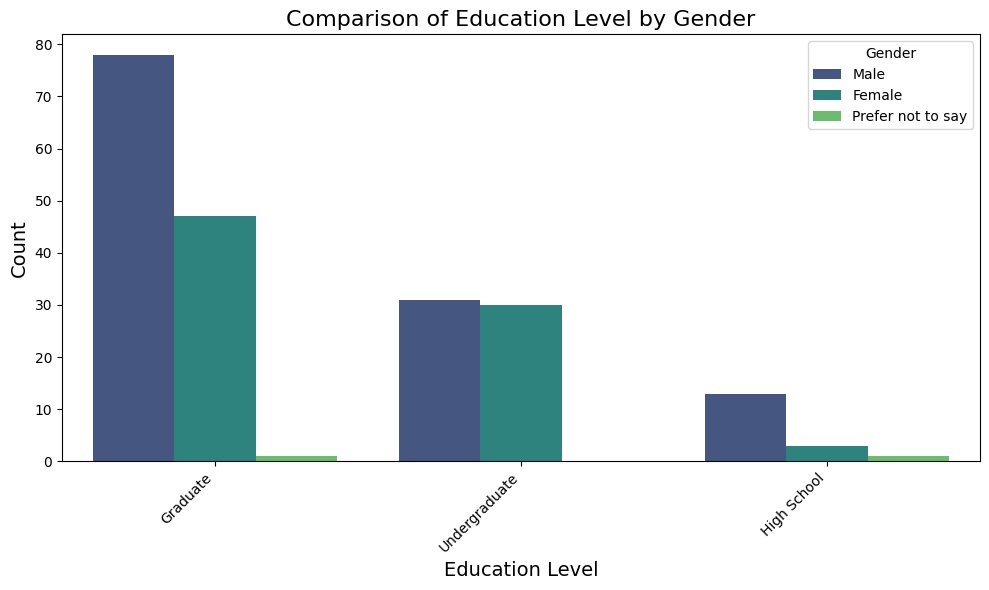

In [16]:
#Comparison between Education Level and Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education_Level', hue='Gender', palette='viridis')
plt.title("Comparison of Education Level by Gender", fontsize=16)
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

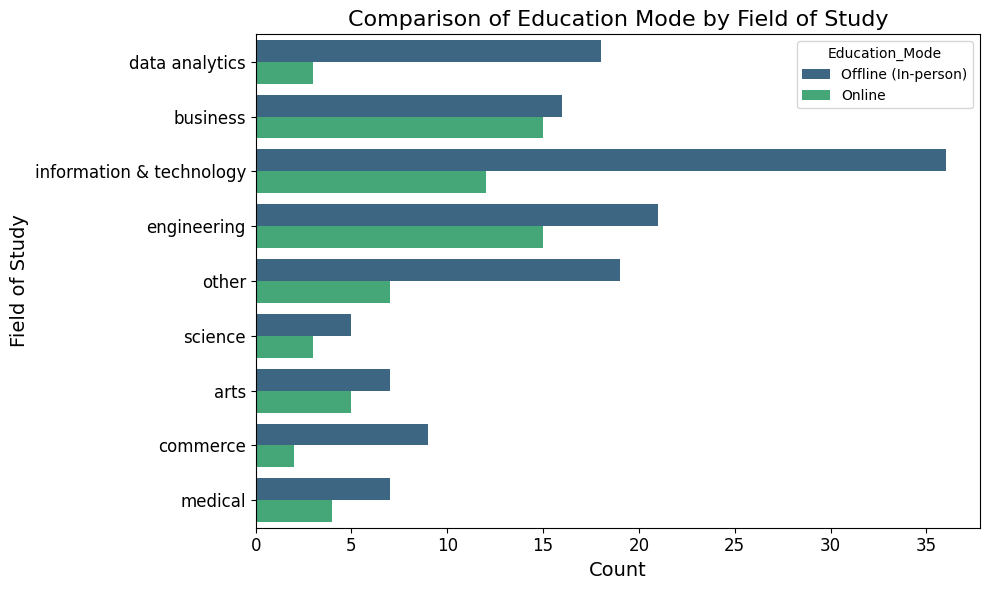

In [17]:
#Comparison between Education Mode and Field of Study (Horizontal)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Field_of_Study', hue='Education_Mode', palette='viridis')
plt.title("Comparison of Education Mode by Field of Study", fontsize=16)
plt.ylabel('Field of Study', fontsize=14)
plt.xlabel('Count', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)  
plt.tight_layout()
plt.show()


Crosstab between Domestic/International and Education Mode:
 Education_Mode                   Offline (In-person)  Online
Domestic_or_International                                   
Domestic student                                  31      12
Foreign (International) student                  107      54


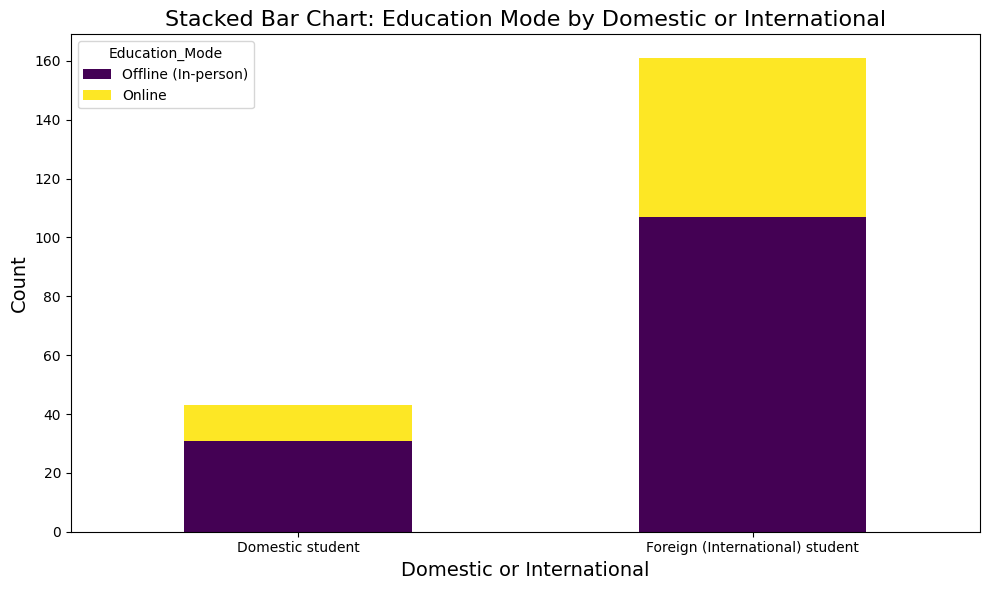

In [18]:
#Comparasion between Domestic/International and Education Mode
education_mode_vs_domestic = pd.crosstab(df['Domestic_or_International'], df['Education_Mode'])
print("\nCrosstab between Domestic/International and Education Mode:\n", education_mode_vs_domestic)

# Plot stacked bar chart for Domestic/International vs Education Mode
education_mode_vs_domestic.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Stacked Bar Chart: Education Mode by Domestic or International", fontsize=16)
plt.xlabel('Domestic or International', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_65608\1168306323.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Online_Student_Engagement', palette='viridis')
C:\Users\dell\AppData\Local\Temp\ipykernel_65608\1168306323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


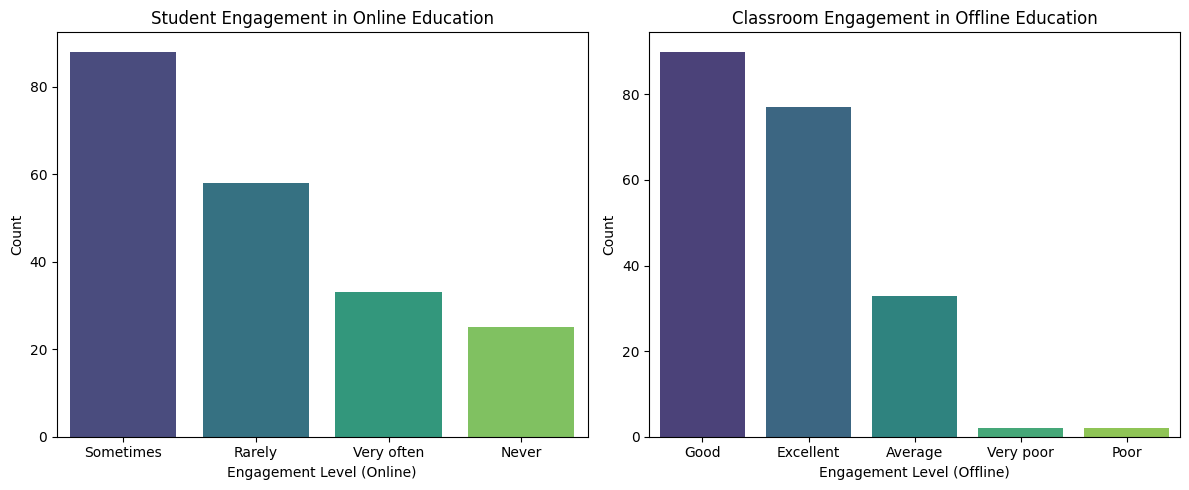

In [19]:
#Evaluate student engagement in online and offline education
engagement_online = df['Online_Student_Engagement'].value_counts()
engagement_offline = df['Offline_Classroom_Engagement'].value_counts()
sorted_order = engagement_offline.index
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Online_Student_Engagement', palette='viridis')
plt.title("Student Engagement in Online Education")
plt.xlabel("Engagement Level (Online)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(
    data=df,
    x='Offline_Classroom_Engagement',
    order=sorted_order,  # Sort bars by descending order
    palette='viridis'
)
plt.title("Classroom Engagement in Offline Education")
plt.xlabel("Engagement Level (Offline)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_65608\3528043782.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=online_factors.values[:5], y=online_factors.index[:5],palette='cool')


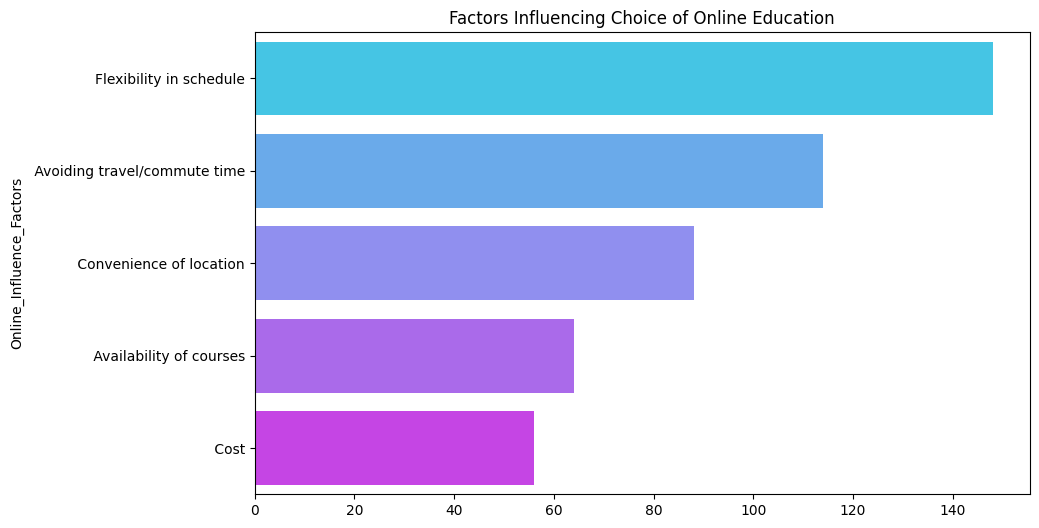

C:\Users\dell\AppData\Local\Temp\ipykernel_65608\3528043782.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=offline_factors.values[:4], y=offline_factors.index[:4],palette='flare')


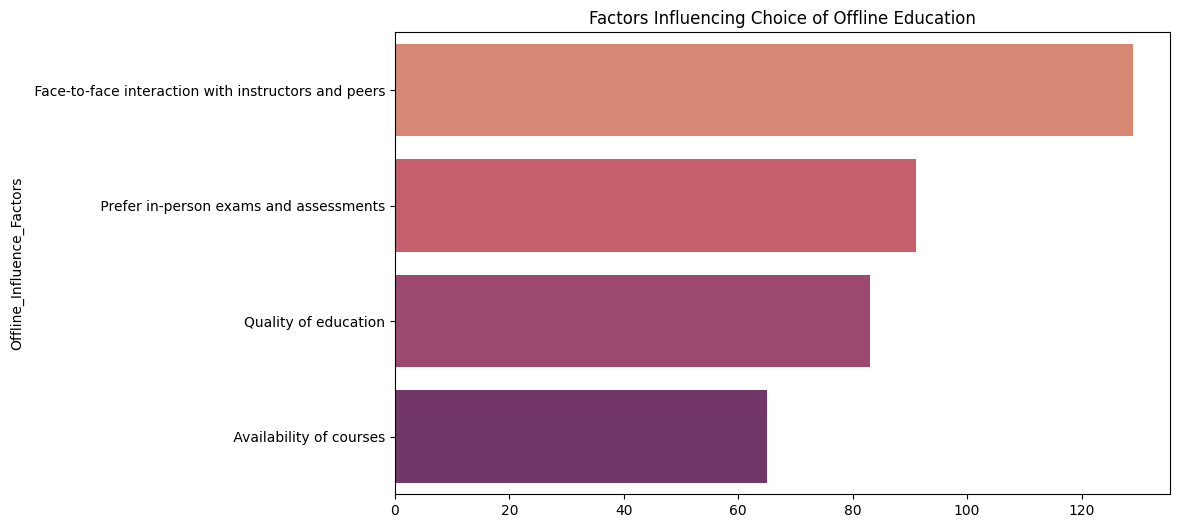

In [20]:
#Identify strengths and weaknesses of online and offline education

online_factors = df[['Online_Effectiveness', 'Online_Challenges', 'Online_Material_Satisfaction', 'Online_Collaboration']].describe()
offline_factors = df[['Offline_Benefits', 'Offline_Resources_Satisfaction', 'Offline_Classroom_Engagement', 'Offline_Motivation']].describe()


online_factors = df['Online_Influence_Factors'].str.split(',').explode().value_counts()
offline_factors = df['Offline_Influence_Factors'].str.split(',').explode().value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=online_factors.values[:5], y=online_factors.index[:5],palette='cool')
plt.title('Factors Influencing Choice of Online Education')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=offline_factors.values[:4], y=offline_factors.index[:4],palette='flare')
plt.title('Factors Influencing Choice of Offline Education')
plt.show()

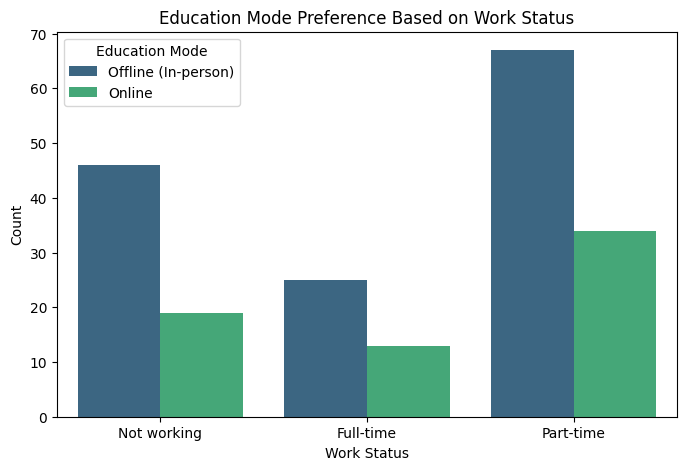

In [21]:
# Investigate factors influencing preferences for online or offline education
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Work_Status', hue='Education_Mode', palette='viridis')
plt.title("Education Mode Preference Based on Work Status")
plt.xlabel("Work Status")
plt.ylabel("Count")
plt.legend(title="Education Mode")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_65608\740722086.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Online_Material_Satisfaction', palette='viridis', order=online_material_satisfaction.index)
C:\Users\dell\AppData\Local\Temp\ipykernel_65608\740722086.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Offline_Resources_Satisfaction', palette='viridis', order=offline_resources_satisfaction.index)


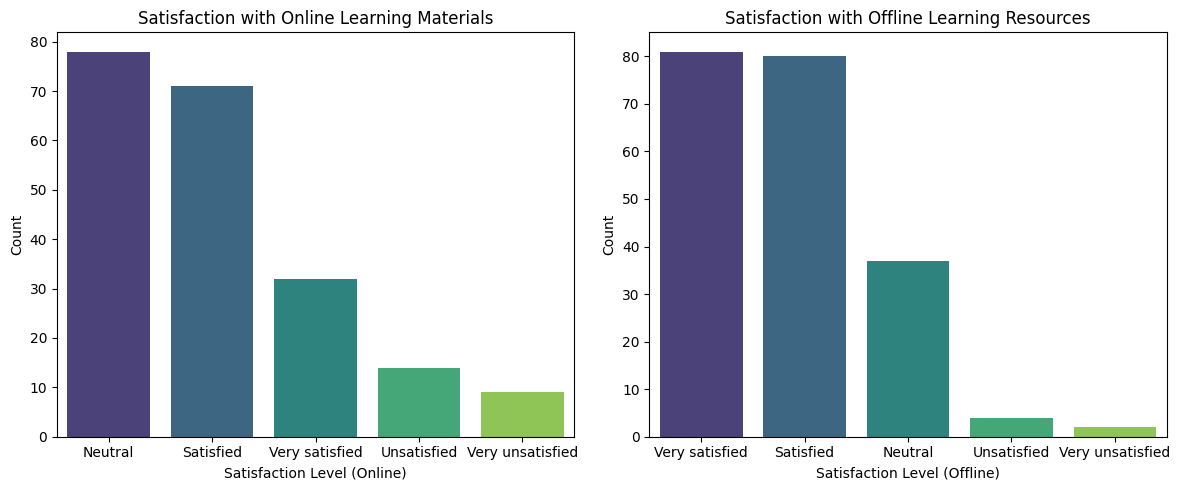

In [22]:
# Satisfaction analysis for online and offline education resources
online_material_satisfaction = df['Online_Material_Satisfaction'].value_counts().sort_values(ascending=False)
offline_resources_satisfaction = df['Offline_Resources_Satisfaction'].value_counts().sort_values(ascending=False)

# Create subplots with sorted satisfaction levels
plt.figure(figsize=(12, 5))

# Plot for Online Material Satisfaction
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Online_Material_Satisfaction', palette='viridis', order=online_material_satisfaction.index)
plt.title("Satisfaction with Online Learning Materials")
plt.xlabel("Satisfaction Level (Online)")
plt.ylabel("Count")

# Plot for Offline Resources Satisfaction
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Offline_Resources_Satisfaction', palette='viridis', order=offline_resources_satisfaction.index)
plt.title("Satisfaction with Offline Learning Resources")
plt.xlabel("Satisfaction Level (Offline)")
plt.ylabel("Count")

# Adjust layout and show plot
plt.tight_layout()
plt.show()



Effectiveness of Online Education:
 Online_Effectiveness
1    21
2    26
3    60
4    51
5    46
Name: count, dtype: int64


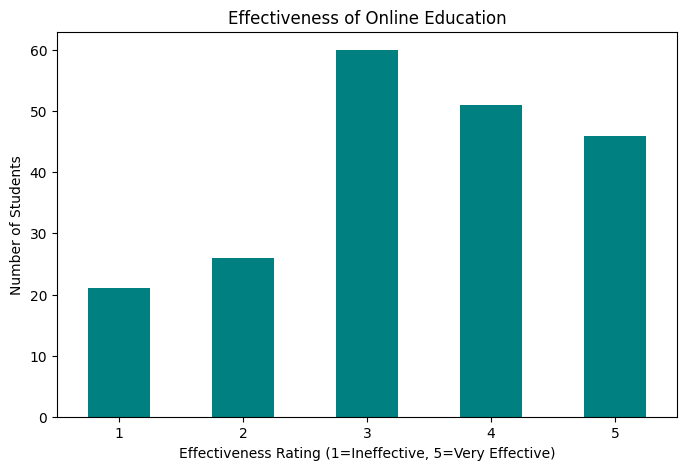

In [23]:
#Analyze the effectiveness of online education
online_effectiveness_summary = df['Online_Effectiveness'].value_counts().sort_index()
print("\nEffectiveness of Online Education:\n", online_effectiveness_summary)

# Plot online education effectiveness
plt.figure(figsize=(8, 5))
online_effectiveness_summary.plot(kind='bar', color='teal', title="Effectiveness of Online Education")
plt.xlabel("Effectiveness Rating (1=Ineffective, 5=Very Effective)")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

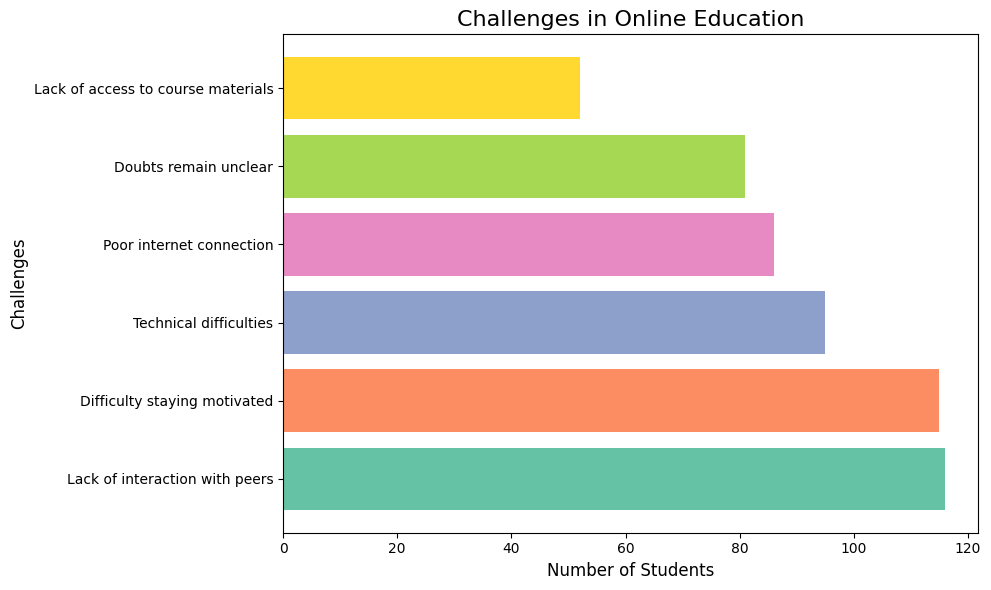

In [24]:
#Analyze the Challenges of online education

def clean_multi_select_column(column):
    # Strip extra spaces and handle entries with commas as whole phrases
    cleaned_values = column.str.split(r',\s*(?![^()]*\))').apply(lambda x: [item.strip() for item in x if item.strip()])
    return cleaned_values

# Clean the columns for Online Challenges and Offline Benefits
online_challenges_expanded = clean_multi_select_column(df['Online_Challenges']).explode().str.strip()
offline_benefits_expanded = clean_multi_select_column(df['Offline_Benefits']).explode().str.strip()

# Get value counts for both variables
online_challenges_summary = online_challenges_expanded.value_counts().head(6)
offline_benefits_summary = offline_benefits_expanded.value_counts().head(6)

# Generate unique colors for each bar
online_colors = sns.color_palette("Set2", len(online_challenges_summary))
offline_colors = sns.color_palette("Set3", len(offline_benefits_summary))

# Plot challenges in online education as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(online_challenges_summary.index, online_challenges_summary.values, color=online_colors)
plt.title("Challenges in Online Education", fontsize=16)
plt.xlabel("Number of Students", fontsize=12)
plt.ylabel("Challenges", fontsize=12)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


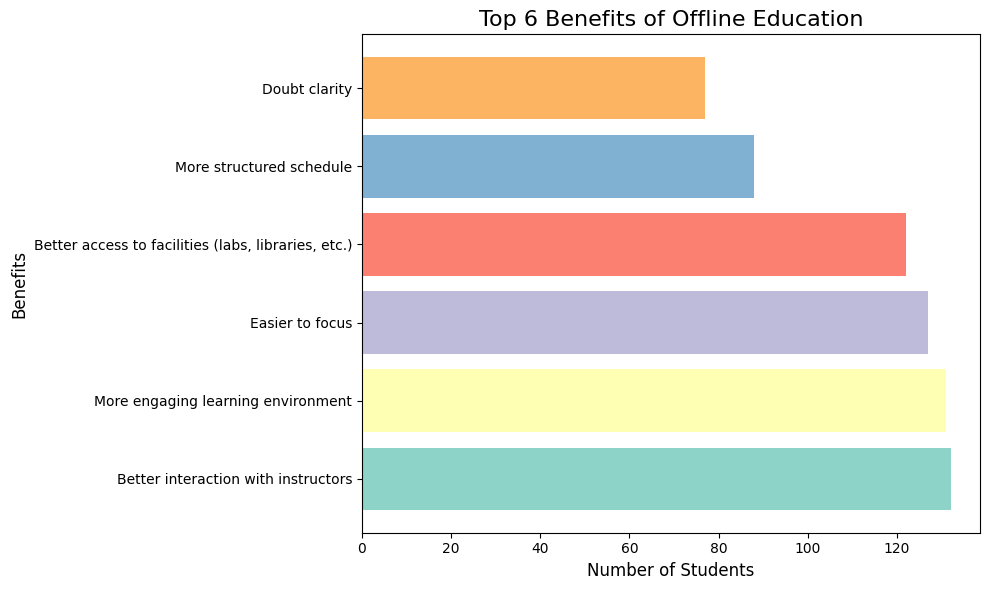

In [25]:
#Analyze the Benefits of offline education
# Plot benefits of offline education as a horizontal bar chart with distinct colors
plt.figure(figsize=(10, 6))
plt.barh(offline_benefits_summary.index, offline_benefits_summary.values, color=offline_colors)
plt.title("Top 6 Benefits of Offline Education", fontsize=16)
plt.xlabel("Number of Students", fontsize=12)
plt.ylabel("Benefits", fontsize=12)
plt.tight_layout()
plt.show()

# Correlation Matrix


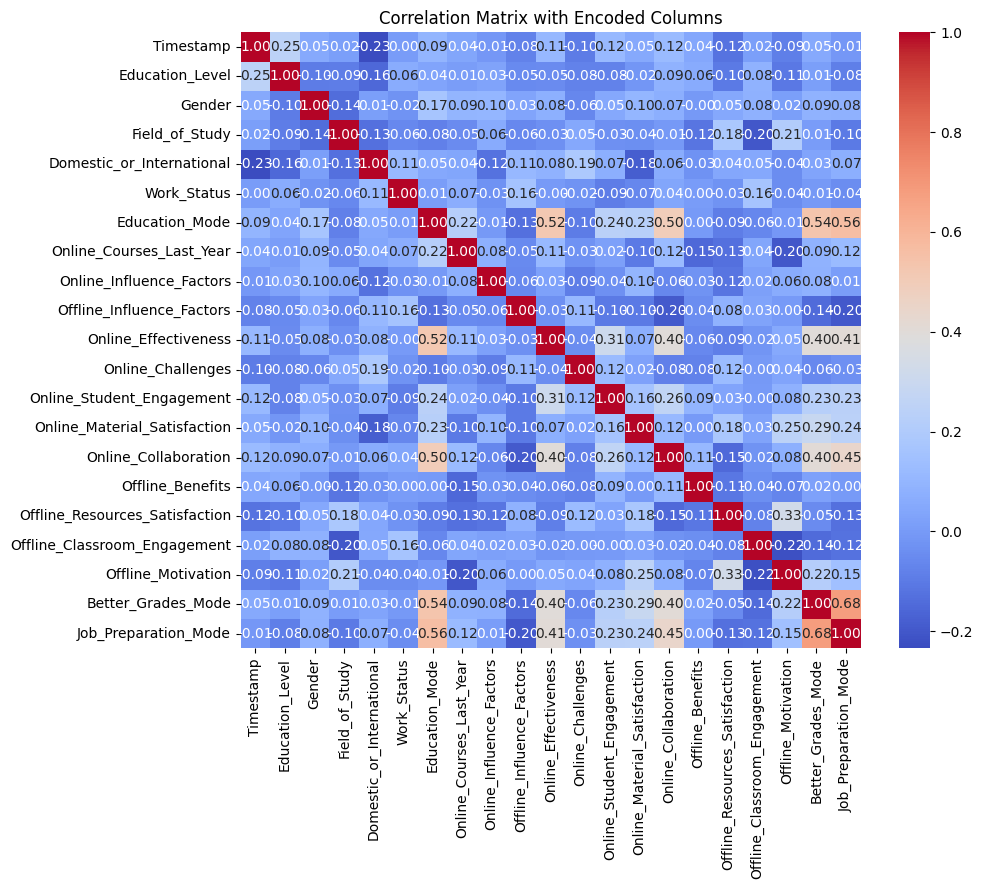

In [26]:
#correlation Matrix
# Convert categorical data to numeric using Label Encoding 
from sklearn.preprocessing import LabelEncoder

encoded_data = df.copy() 
label_encoders = {}

categorical_cols = encoded_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    encoded_data[col] = le.fit_transform(encoded_data[col])
    label_encoders[col] = le 

# Recalculate the correlation matrix with encoded columns
correlation_matrix = encoded_data.corr()

# Plot the updated heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix with Encoded Columns")
plt.show()